In [2]:
# --- Imports ---
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import set_random_seed

c:\Users\kelvy\anaconda3\envs\stat5810\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [44]:
set_random_seed(12345)
n = 400  # increase to 1000 if needed

# Generate data
v1 = np.random.uniform(-1, 1, n)
v2 = np.random.uniform(-1, 1, n)
v3 = np.random.uniform(-1, 1, n)

# Define response variable y
y = np.where(v1 < -1/3, 0,
             np.where(v2 > -1/3, 1, 0))
# y = y.astype("category")

# Create dataframe
dfc = pd.DataFrame({"v1": v1, "v2": v2, "v3": v3, "y": y})

# Create factor-like variables (boolean → categorical)
z1 = (dfc["v1"] > -1/3).astype("category")
z2 = (dfc["v2"] > -1/3).astype("category")

# --- dataset ---
X = dfc[["v1", "v2", "v3"]].values  # as NumPy array
y = dfc["y"]#.cat.codes              # convert categorical to numeric codes (0,1,...)

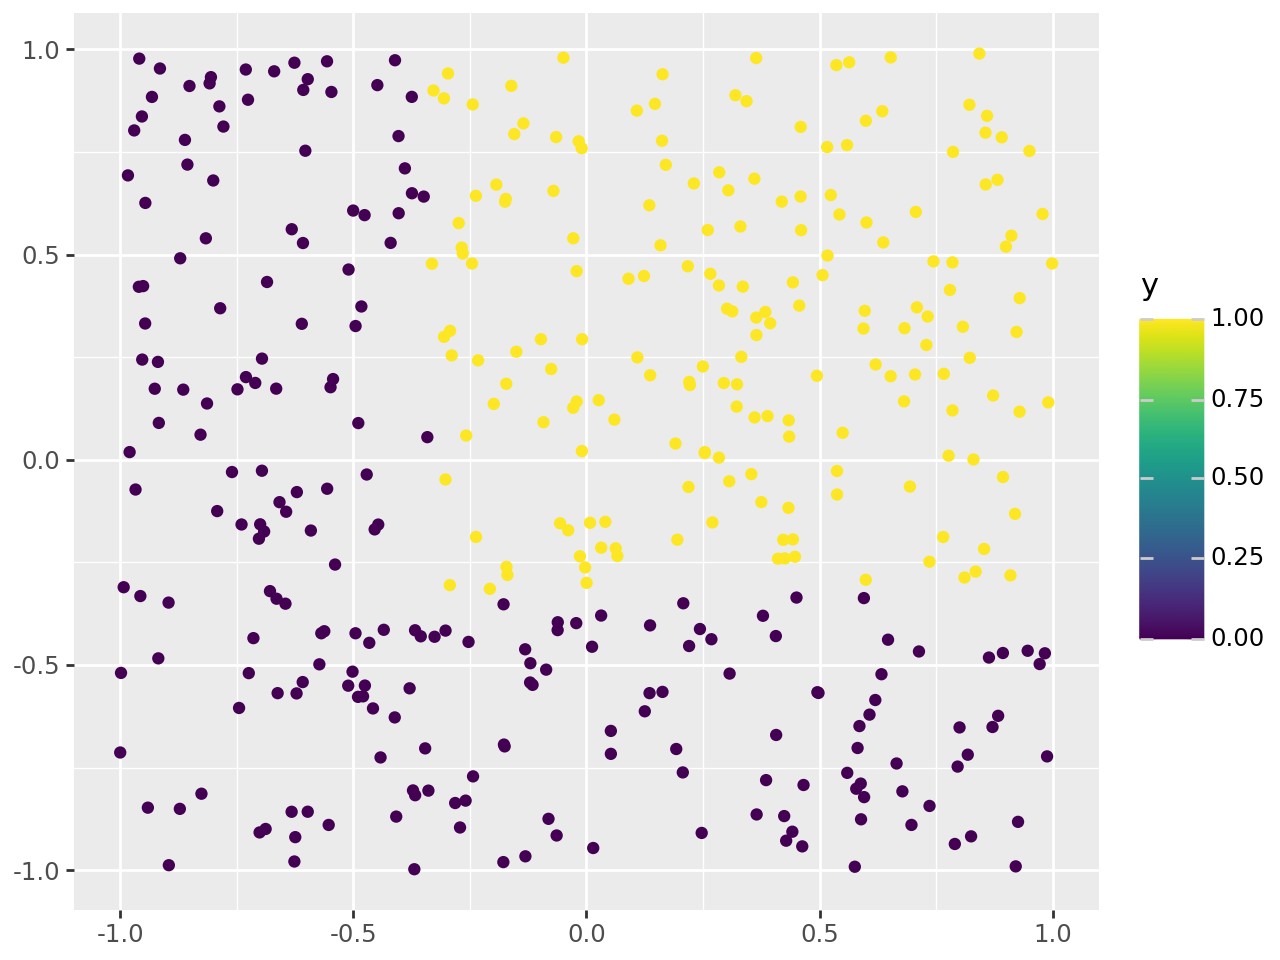

In [51]:
import plotnine as p9

gg = (
    p9.ggplot(dfc, p9.aes(x = v1, y = v2, color = y)) +
    p9.geom_point()
    )

gg

In [61]:
# --- Define MLP model builder ---
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [12]:
def clique(X, y, model_builder="rf", folds=5, nsim=25, quantile_grid=True, keras_model=False, 
            epochs=10, batch_size=32, random_state=123):
    """
    Python translation of the R clique function.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor matrix
    y : pd.Series or np.array
        Response vector (numeric for regression, categorical for classification)
    model_type : str
        "rf" for random forest, "lm" for linear regression
    param_grid : dict
        Parameters for the chosen model (like tuneGrid in caret)
    nsim : int
        Number of grid points
    folds : int
        Number of CV folds
    quantile_grid : bool
        Whether to use quantiles (True) or uniform grid (False)
    random_state : int
        Reproducibility
    
    Returns
    -------
    dict with:
        - "models": list of fitted models (per fold)
        - "local_imp": pd.DataFrame of local importance values
    """
        
    X = pd.DataFrame(X)
    y = pd.Series(y)

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    models = []
    
    # Train fold-specific models
    for train_idx, test_idx in skf.split(X, y):
        if model_builder == "rf":
            model = RandomForestClassifier(n_estimators=100, random_state=random_state)
        elif keras_model:
            model = model_builder(X.shape[1])  # build keras model
        else:
            model = model_builder  # assume it's already an sklearn estimator

        if keras_model:
            model.fit(X.iloc[train_idx], y.iloc[train_idx],
                      epochs=epochs, batch_size=batch_size, verbose=0,
                      validation_data=(X.iloc[test_idx], y.iloc[test_idx]))
        else:
            model.fit(X.iloc[train_idx], y.iloc[train_idx])

        models.append(model)

    # Collect predictions (truth vs. preds)
    truth = y.values
    preds = np.zeros_like(truth, dtype=float)

    for fold, (_, test_idx) in enumerate(skf.split(X, y)):
        if keras_model:
            preds[test_idx] = models[fold].predict(X.iloc[test_idx]).ravel()
        else:
            preds[test_idx] = models[fold].predict_proba(X.iloc[test_idx])[:, 1]

    base_mse = (truth - preds) ** 2

    # Importance calculation
    local_imp = pd.DataFrame(0, index=X.index, columns=X.columns)

    for i, col in enumerate(X.columns):
        if np.issubdtype(X[col].dtype, np.number):
            grid_vals = np.quantile(X[col], np.linspace(0, 1, nsim)) if quantile_grid else np.linspace(X[col].min(), X[col].max(), nsim)
        else:
            grid_vals = X[col].unique()

        for val in grid_vals:
            X_new = X.copy()
            X_new[col] = val
            new_preds = np.zeros_like(truth, dtype=float)

            for fold, (_, test_idx) in enumerate(skf.split(X, y)):
                if keras_model:
                    new_preds[test_idx] = models[fold].predict(X_new.iloc[test_idx]).ravel()
                else:
                    new_preds[test_idx] = models[fold].predict_proba(X_new.iloc[test_idx])[:, 1]

            new_mse = (truth - new_preds) ** 2
            local_imp[col] += (new_mse - base_mse) / nsim

    return {"models": models, "local_imp": local_imp}

In [45]:
res = clique(X=pd.DataFrame(X), y=pd.Series(y), model_builder="rf", nsim=25, folds=3)

In [32]:
res["local_imp"].describe().drop(["count", "mean", "std"])

,0,1,2
min,-0.282375,-0.315035,-0.178270
25%,0.001103,0.001400,0.000089
50%,0.273813,0.301542,0.001670
75%,0.318507,0.341730,0.004636
max,0.665265,0.633570,0.098795


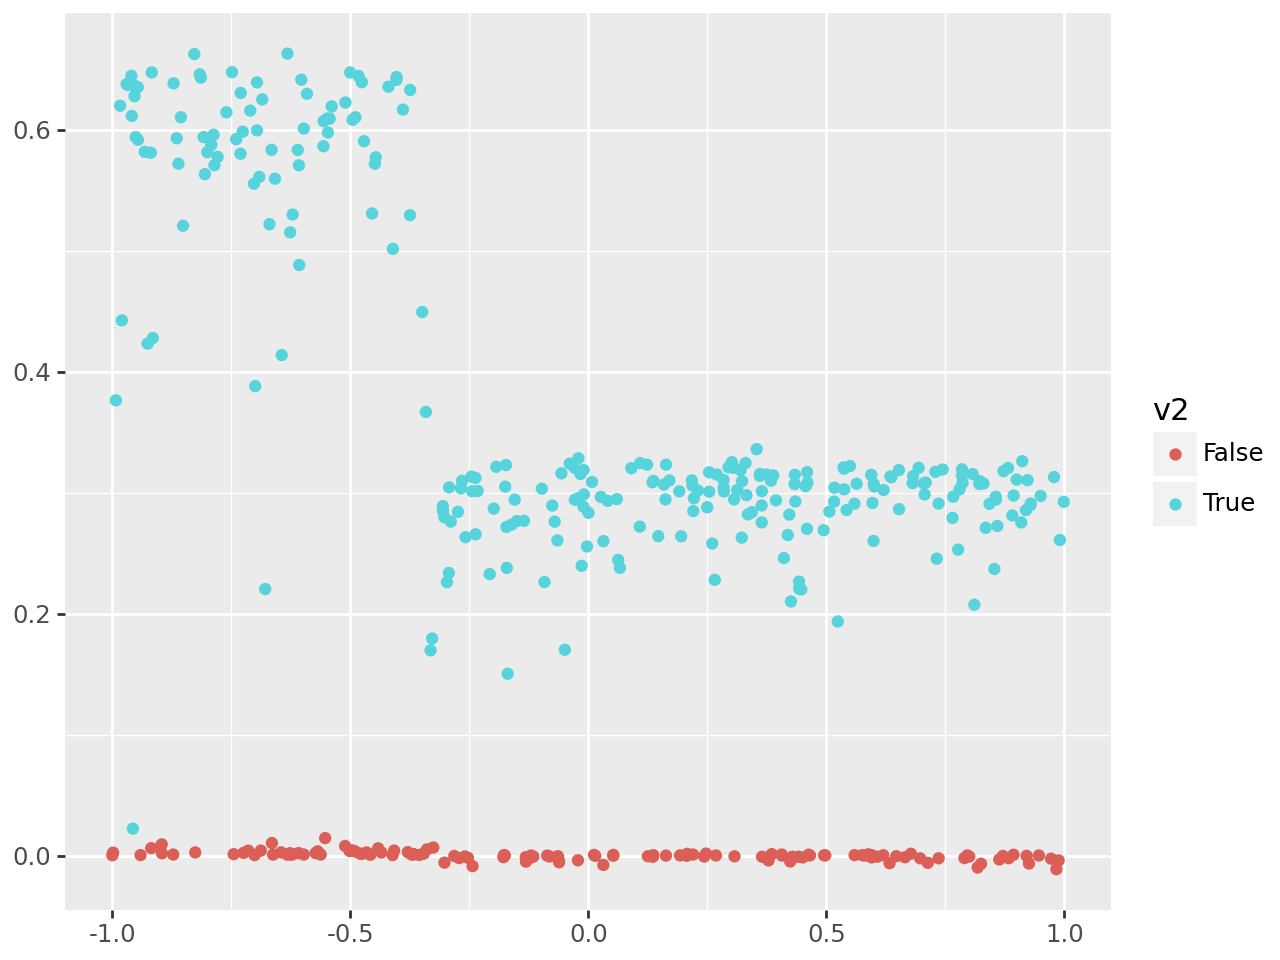

In [46]:
gg = (
    p9.ggplot(dfc, p9.aes(x = v1, y = res["local_imp"][0], color = z2)) +
    p9.geom_point()
    )

gg

In [62]:
res_mlp = clique(X, y, model_builder=build_mlp, quantile_grid=True,
                  folds=3, nsim=25, keras_model=True, epochs=50, batch_size=32)

5/5 [==============================] - 0s 0s/step


In [63]:
res_mlp["local_imp"]

,0,1,2
0,0.303502,0.296714,0.000000
1,-0.000000,0.087358,0.000000
2,-0.000001,0.000107,-0.000001
3,0.539114,0.000017,0.000409
4,-0.000131,0.633093,-0.000071
...,...,...,...
395,0.320377,0.312519,-0.000000
396,0.324974,0.306851,-0.000000
397,0.618353,-0.000016,-0.000010
398,0.240146,0.276971,0.013473


In [64]:
pd.options.display.float_format = '{:.6f}'.format
res_mlp["local_imp"].describe().drop(["count", "mean", "std"])

,0,1,2
min,-0.179787,-0.221130,-0.245435
25%,0.000074,0.000060,-0.000000
50%,0.296036,0.300903,0.000000
75%,0.321634,0.322116,0.000017
max,0.696235,0.666500,0.403471


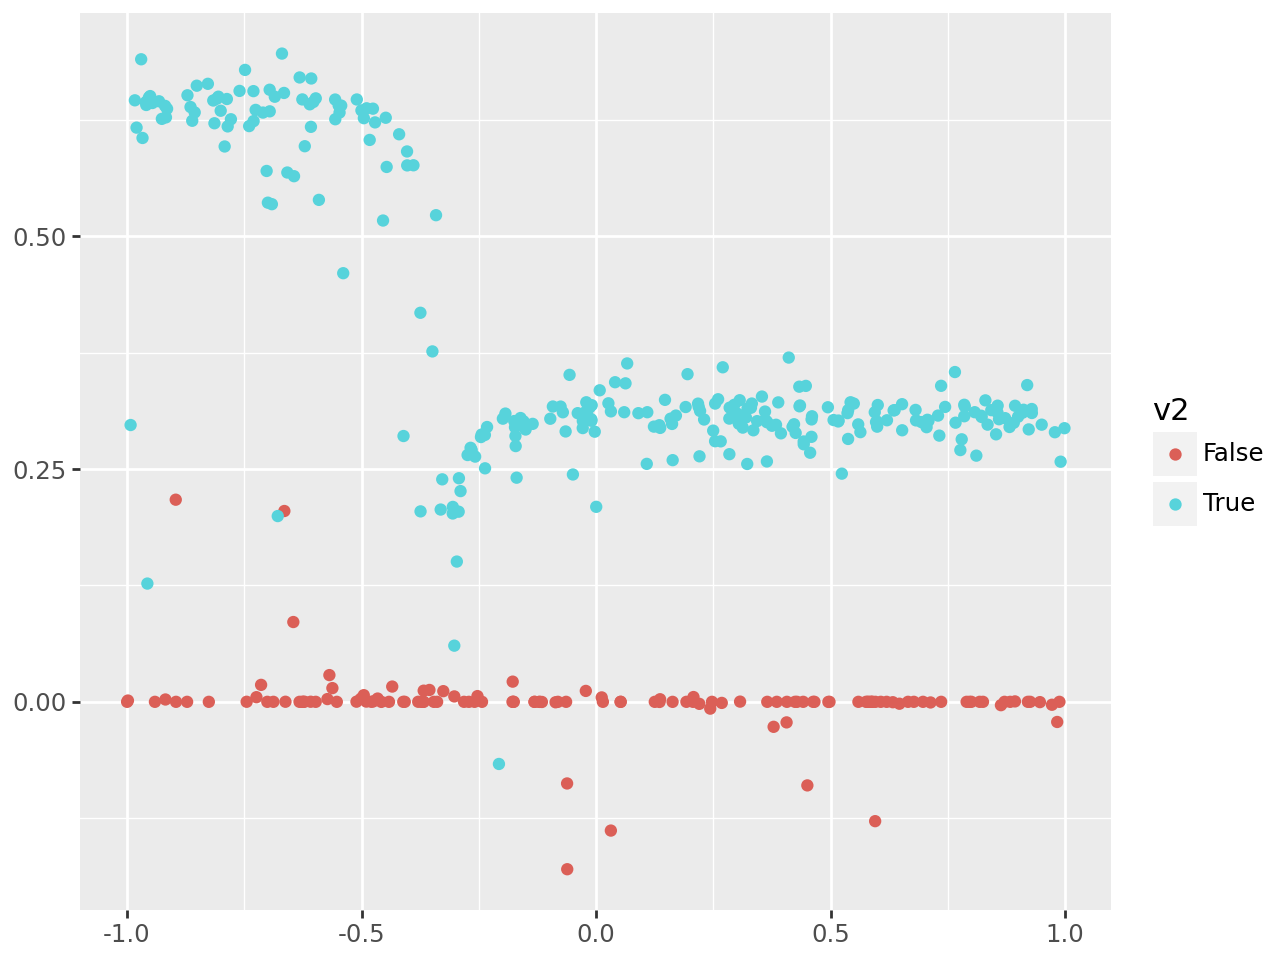

In [65]:
gg = (
    p9.ggplot(dfc, p9.aes(x = v1, y = res_mlp["local_imp"][0], color = z2)) +
    p9.geom_point()
    )

gg

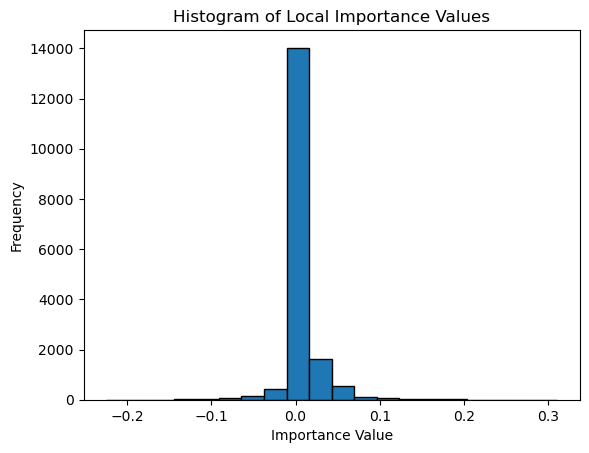

In [50]:
import matplotlib.pyplot as plt

plt.hist(res_mlp["local_imp"].values.flatten(), bins=20, edgecolor='k')
plt.title("Histogram of Local Importance Values")
plt.xlabel("Importance Value")
plt.ylabel("Frequency")
plt.show()

In [39]:
# --- 2-Fold Cross Validation ---
kf = KFold(n_splits=2, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Build and train model
    model = build_mlp(input_dim=X.shape[1])
    model.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=10,
              batch_size=32,
              verbose=0)
    
    # Evaluate
    y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

# --- Mean accuracy across folds ---
print("\nMean CV Accuracy:", np.mean(fold_accuracies).round(4))


--- Fold 1 ---
9/9 [==============================] - 0s 1ms/step
Fold 1 Accuracy: 0.9719

--- Fold 2 ---
9/9 [==============================] - 0s 2ms/step
Fold 2 Accuracy: 0.9542

Mean CV Accuracy: 0.9631
